# Random Forest

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [17]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from time import perf_counter

from sklearn.datasets import make_moons
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier as SklearnDecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier as SklearnRandomForestClassifier

from models.decision_tree import DecisionTree
from models.random_forest import RandomForest

from metrics.classification import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
from utils.plots import plot_decision_boundary
from utils.tests import parameter_sweep_trees

## Dataset
We use the same dataset that was used to test the Decision Tree model in order to compare performances.

### Generation and Split

In [3]:
X, y = make_moons(
    n_samples=1000,
    noise=0.25,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

### Plotting

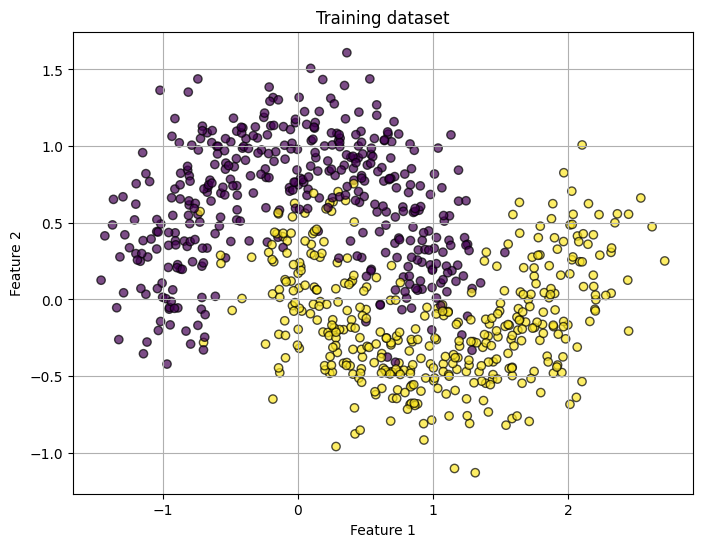

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[:, 0],
    X_train[:, 1],
    c=y_train,
    alpha=0.7,
    edgecolor="k",
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training dataset")
plt.grid(True)

plt.show()

## Comparison with Decision Tree and `sklearn` Random Forest

### Single Split
I test the scratch forest against the scratch tree and the sklearn forest on one random state. As expected, the scratch forest is much slower than the sklearn forest, but in this case the metrics for the single tree are actualy slightly better than those of both forests.

This is likely due to the fact that we used the same dataset as the previous notebook and chose the optimum max depth, which enabled us to obtain an accuracy of $0.98$ for the single tree, which can't be improved upon much. The forest may smooth out some sharp tree decisions, which can slightly hurt if the single tree happened to fit this split very well.

A random forest does not guarantee better performance than the best single tree on one train/test split. It usually improves generalization stability by reducing variance.

However, from the decision boundary plots we can see that the boundaries are much smoother in the forest cases, and there are less signals of overfitting. 

The `sklearn` model works slightly better than the scratch one due to its tree model being more optimized. The differences, almost unnoticeable for a single tree, accumulate in the forest because the final classifier depends on the aggregate vote of many independently trained trees.

The next thing to do is trying to average the metrics over multiple splits. This should show that the forests are more stable than the single tree, thus the metrics will have a lower variance.

In [9]:
scratch_tree = DecisionTree(
    max_depth=7,
    min_samples_split=2,
    random_state=42,
)

scratch_forest = RandomForest(
    n_trees=50,
    max_depth=7,
    min_samples_split=2,
    n_features=None,
    random_state=42,
)

sklearn_forest = SklearnRandomForestClassifier(
    n_estimators=50,
    max_depth=7,
    min_samples_split=2,
    criterion="entropy",
    random_state=42,
)

### Fit and Predict

In [10]:
models = {
    "Single tree": scratch_tree,
    "From-scratch forest": scratch_forest,
    "Scikit-learn forest": sklearn_forest,
}

results = {}

for name, model in models.items():
    start = perf_counter()
    model.fit(X_train, y_train)
    fit_time = perf_counter() - start

    start = perf_counter()
    preds = model.predict(X_test)
    predict_time = perf_counter() - start

    results[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds),
        "Fit time": fit_time,
        "Predict time": predict_time,
    }

results_df = pd.DataFrame(results).T
results_df

,Accuracy,Precision,Recall,F1,Fit time,Predict time
Single tree,0.925,0.912621,0.94,0.926108,0.413802,0.000293
From-scratch forest,0.925,0.904762,0.95,0.926829,15.584924,0.029105
Scikit-learn forest,0.930,0.913462,0.95,0.931373,0.175503,0.006952


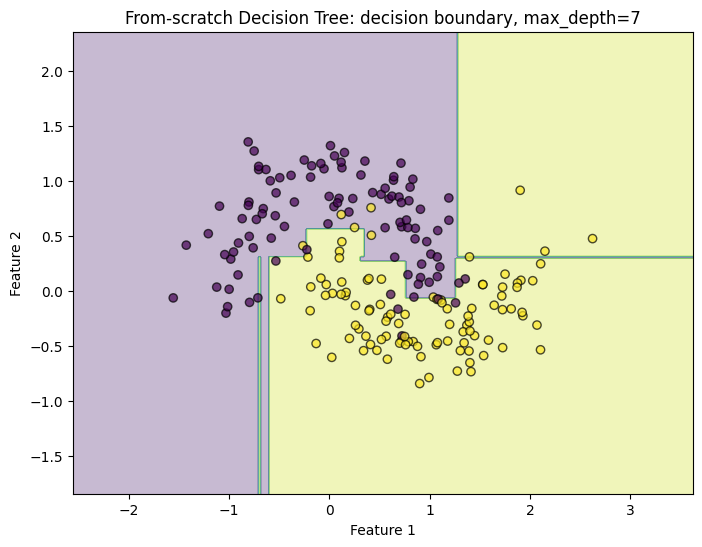

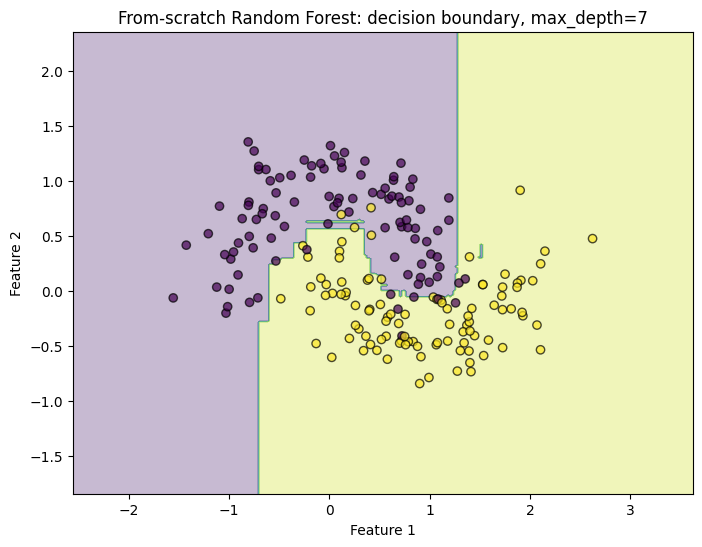

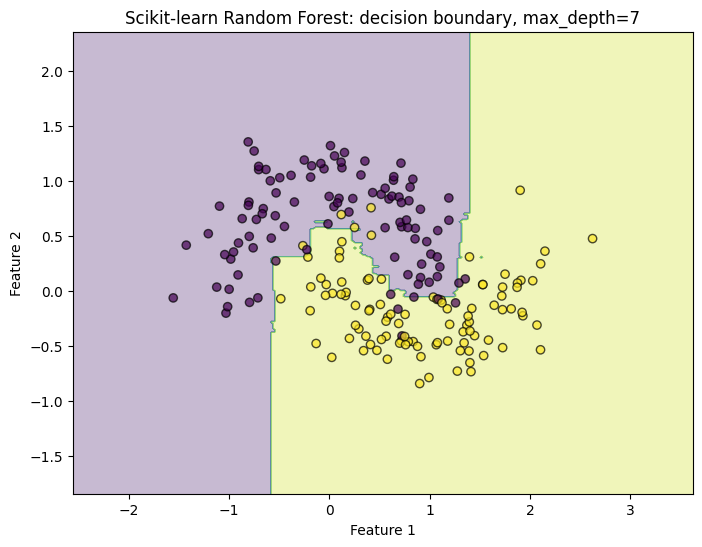

In [13]:
plot_decision_boundary(
    scratch_tree,
    X_test,
    y_test,
    "From-scratch Decision Tree: decision boundary, max_depth=7"
)

plot_decision_boundary(
    scratch_forest,
    X_test,
    y_test,
    "From-scratch Random Forest: decision boundary, max_depth=7"
)

plot_decision_boundary(
    sklearn_forest,
    X_test,
    y_test,
    "Scikit-learn Random Forest: decision boundary, max_depth=7"
)

### Multiple Splits
The results confirm our earlier prediction: Both the mean and the standard deviation of the metrics averaged over 30 splits are better for the forests than for the single tree. The effect is still not that visible, due to the fact that this is a simple dataset to begin with.

In [7]:
seeds = range(30)

rows = []

for seed in seeds:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=seed,
        stratify=y,
    )

    models = {
        "Single tree": DecisionTree(max_depth=7, random_state=seed),
        "From-scratch forest": RandomForest(
            n_trees=50,
            max_depth=7,
            random_state=seed,
        ),
        "Scikit-learn forest": SklearnRandomForestClassifier(
            n_estimators=50,
            max_depth=7,
            criterion="entropy",
            random_state=seed,
        ),
    }

    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        rows.append({
            "seed": seed,
            "model": name,
            "accuracy": accuracy_score(y_test, preds),
            "f1": f1_score(y_test, preds),
        })

stability_df = pd.DataFrame(rows)

In [8]:
stability_df.groupby("model")[["accuracy", "f1"]].agg(["mean", "std"])

accuracy                  f1          
                         mean       std      mean       std
model                                                      
From-scratch forest  0.940000  0.014020  0.940951  0.013454
Scikit-learn forest  0.945167  0.013739  0.945647  0.013179
Single tree          0.928000  0.018080  0.929052  0.017359

## Harder Dataset

In this case we are not going to do the hyperparameter sweeps on the simpler dataset, because a single tree is already the best choice for that, and using a forest would not get any improvements.

In [26]:
X, y = make_classification(
    n_samples=3000,
    n_features=20,
    n_informative=8,
    n_redundant=6,
    n_repeated=0,
    n_classes=2,
    flip_y=0.08,
    class_sep=0.8,
    random_state=42,
)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

### Hyperparameter Sweeps

#### Number of Trees
We can distinguish 4 regimes:
- *few trees*: unstable, low recall/F1
- *$\sim10-30$ trees*: large improvement
- *$\sim40-60$ trees*: saturation
- *$>60$ trees*: marginal gains only

Since the implementation of the forest from scratch is not optimized at all, computing this plot took more than 3 hours. The plot of the fit time vs. the number of trees shows that the time increases linearly with the number of trees, which is coherent with the fact that adding a tree means repeating all the operations one more time. This makes it impossible to try and test multiple random splits for each number of trees, to observe the mean and standard deviation of the metrics. Optionally, this could be done using the much faster sklearn implementation.

In [29]:
tree_values = list(range(1,11)) + list(range(15,51,5)) + list(range(60,101,10))
sweep_results = parameter_sweep_trees(
    model_cls=RandomForest, 
    param_grid={
        'n_trees': tree_values
    }, 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test, 
    base_params={
        'random_state': 42,
        'max_depth': 7
    }
)

sweep_df = pd.DataFrame(sweep_results)

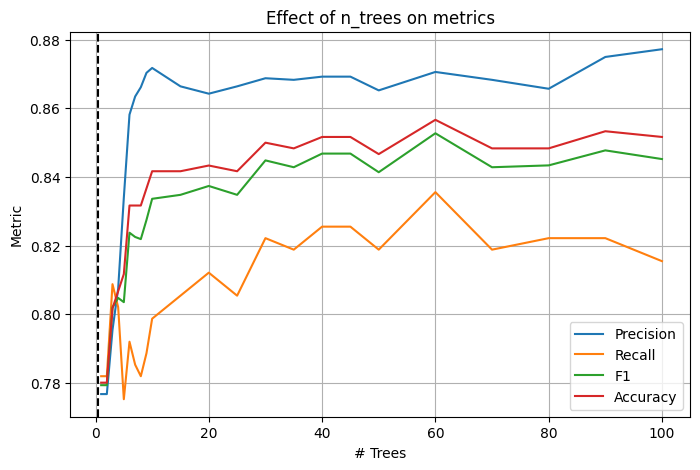

In [31]:
plt.figure(figsize=(8, 5))

plt.axvline(0.5, ymin=0., ymax=1, ls='--', c='k')
plt.plot(sweep_df["n_trees"], sweep_df["test_precision"], label="Precision")
plt.plot(sweep_df["n_trees"], sweep_df["test_recall"], label="Recall")
plt.plot(sweep_df["n_trees"], sweep_df["test_f1"], label="F1")
plt.plot(sweep_df["n_trees"], sweep_df["test_accuracy"], label="Accuracy")

plt.xlabel("# Trees")
plt.ylabel("Metric")
plt.title("Effect of n_trees on metrics")
plt.legend()
plt.grid(True)

plt.show()

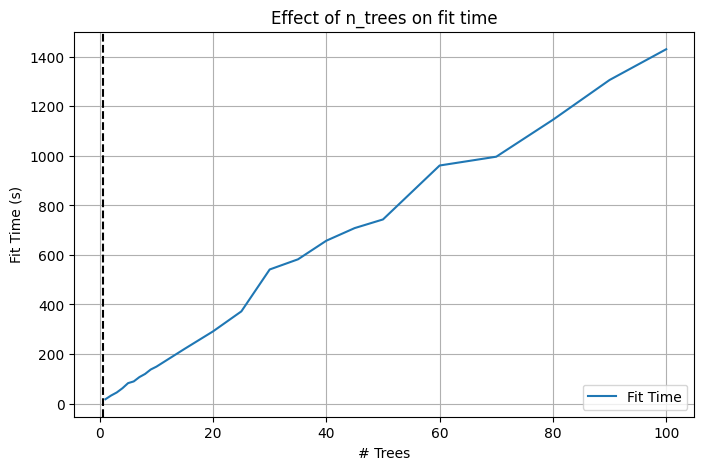

In [33]:
plt.figure(figsize=(8, 5))

plt.axvline(0.5, ymin=0., ymax=1, ls='--', c='k')
plt.plot(sweep_df["n_trees"], sweep_df["fit_time"], label="Fit Time")

plt.xlabel("# Trees")
plt.ylabel("Fit Time (s)")
plt.title("Effect of n_trees on fit time")
plt.legend()
plt.grid(True)

plt.show()